In [1]:
# --- Imports & global style ---
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, Optional, Tuple

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

In [2]:
# --- Configuration ---
# Set this to your repository folder (or keep "." if you run from the project root).
PROJECT_ROOT = Path(".").resolve()

# Where experiment outputs live (relative to PROJECT_ROOT)
OUTPUT_DIR = PROJECT_ROOT / "output_by_scores"
FIGURES_DIR = PROJECT_ROOT / "figures_pretty"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /home/dsi/chenbis/repos/sol_lab/clustering models prediction
OUTPUT_DIR: /home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores
FIGURES_DIR: /home/dsi/chenbis/repos/sol_lab/clustering models prediction/figures_pretty


In [3]:
# --- Utilities ---
def _safe_literal_eval(x: Any) -> Any:
    if not isinstance(x, str):
        return x
    x = x.strip()
    if not x:
        return {}
    try:
        return ast.literal_eval(x)
    except Exception:
        # If parsing fails, return original string to avoid breaking the pipeline.
        return x


def _ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def _savefig(path: Path) -> None:
    _ensure_dir(path.parent)
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()

In [4]:
# --- Loaders ---
def load_training_stats(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Parse dict-like columns if present
    if "params" in df.columns:
        df["params_dict"] = df["params"].apply(_safe_literal_eval)
    else:
        df["params_dict"] = [{} for _ in range(len(df))]

    if "clusters" in df.columns:
        df["clusters_dict"] = df["clusters"].apply(_safe_literal_eval)
    else:
        df["clusters_dict"] = [{} for _ in range(len(df))]

    # Common hyperparameters (NaN if absent)
    def _get(d: Any, k: str) -> float:
        return float(d.get(k, np.nan)) if isinstance(d, dict) and k in d else np.nan

    for k in ["n_clusters", "eps", "min_samples"]:
        df[k] = df["params_dict"].apply(lambda d, kk=k: _get(d, kk))

    # Normalize metric columns (expected: f1_score, precision, recall, etc.)
    # Keep as-is if your CSV already uses these names.
    return df


def load_test_metrics(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Parse params if present
    if "params" in df.columns and "params_dict" not in df.columns:
        df["params_dict"] = df["params"].apply(_safe_literal_eval)

    return df

In [5]:
# --- Plotting helpers (thesis-friendly) ---
def best_f1_per_method_barplot(train_df: pd.DataFrame, outpath: Path, metric: str = "f1_score") -> pd.DataFrame:
    required = {"method", metric}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns: {sorted(missing)}")

    best = (
        train_df.dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby("method", as_index=False)
        .head(1)
        .sort_values(metric, ascending=True)
    )

    plt.figure()
    plt.barh(best["method"], best[metric])
    plt.xlabel(metric.replace("_", "-"))
    plt.title(f"Best training {metric.replace('_','-')} per method")
    _savefig(outpath)

    return best


def f1_vs_param_lineplot(
    train_df: pd.DataFrame,
    method: str,
    param_col: str,
    outpath: Path,
    metric: str = "f1_score",
) -> None:
    required = {"method", metric, param_col}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns: {sorted(missing)}")

    sub = train_df[(train_df["method"] == method) & train_df[param_col].notna() & train_df[metric].notna()].copy()
    if sub.empty:
        print(f"[WARN] No rows for method={method!r} with param {param_col!r}. Skipping plot.")
        return

    sub = sub.sort_values(param_col)

    plt.figure()
    plt.plot(sub[param_col].values, sub[metric].values, marker="o", linestyle="-")
    plt.xlabel(param_col)
    plt.ylabel(metric.replace("_", "-"))
    plt.title(f"{metric.replace('_','-')} vs {param_col} ({method})")
    _savefig(outpath)


def cluster_size_hist_best_run(
    train_df: pd.DataFrame,
    outpath: Path,
    metric: str = "f1_score",
    bins: int = 30,
) -> None:
    required = {metric, "clusters_dict"}
    missing = required - set(train_df.columns)
    if missing:
        raise ValueError(f"train_df missing columns: {sorted(missing)}")

    best = train_df.dropna(subset=[metric]).sort_values(metric, ascending=False).iloc[0]
    clusters = best["clusters_dict"]

    if not isinstance(clusters, dict) or len(clusters) == 0:
        print("[WARN] Best run has no parsable clusters_dict. Skipping histogram.")
        return

    # Typical structure: {cluster_id: size, ...}
    sizes = [v for v in clusters.values() if isinstance(v, (int, float)) and v >= 0]
    if not sizes:
        print("[WARN] No numeric cluster sizes found. Skipping histogram.")
        return

    sizes = np.array(sizes, dtype=float)

    plt.figure()
    plt.hist(sizes, bins=bins)
    plt.xlabel("Cluster size (# items)")
    plt.ylabel("Number of clusters")
    title_method = best["method"] if "method" in train_df.columns else "best run"
    plt.title(f"Cluster size distribution ({title_method}, best {metric.replace('_','-')})")

    # Optional thesis-friendly annotations
    mean_sz = float(np.mean(sizes))
    med_sz = float(np.median(sizes))
    plt.axvline(mean_sz, linestyle="--")
    plt.axvline(med_sz, linestyle=":")

    _savefig(outpath)

In [6]:
# --- Summaries & multi-dataset comparison ---
def build_summary_table(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    metric: str = "f1_score",
) -> pd.DataFrame:

    if "method" not in train_df.columns:
        raise ValueError("train_df must contain a 'method' column")
    if metric not in train_df.columns:
        raise ValueError(f"train_df must contain '{metric}'")

    best_train = (
        train_df.dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby("method", as_index=False)
        .head(1)
        .copy()
    )

    # Columns to keep from train
    keep_train = ["method", metric]
    for c in ["precision", "recall", "accuracy"]:
        if c in best_train.columns:
            keep_train.append(c)
    for c in ["n_clusters", "eps", "min_samples"]:
        if c in best_train.columns:
            keep_train.append(c)
    if "params" in best_train.columns:
        keep_train.append("params")

    summary = best_train[keep_train].rename(columns={metric: f"train_{metric}"})

    # Merge test
    if test_df is None or len(test_df) == 0:
        print("[WARN] Empty test_df; returning train-only summary.")
        return summary

    # Prefer (method, params) merge when possible
    merge_keys = []
    if "method" in test_df.columns:
        merge_keys.append("method")
    if "params" in summary.columns and "params" in test_df.columns:
        merge_keys.append("params")

    if merge_keys:
        merged = pd.merge(
            summary,
            test_df,
            on=merge_keys,
            how="left",
            suffixes=("", "_test"),
        )
        return merged

    print("[WARN] test_df has no 'method' (and no merge keys). Returning train-only summary.")
    return summary


def plot_dataset_comparison(
    summary_by_dataset: Dict[str, pd.DataFrame],
    outpath: Path,
    metric: str = "f1_score",
) -> None:
    candidates = [metric, f"test_{metric}", f"{metric}_test"]
    plt.figure()

    # Find all methods across datasets
    all_methods = sorted(set().union(*[set(df.get("method", [])) for df in summary_by_dataset.values()]))

    x = np.arange(len(all_methods))
    width = 0.8 / max(1, len(summary_by_dataset))

    for i, (ds_name, df) in enumerate(summary_by_dataset.items()):
        col = next((c for c in candidates if c in df.columns), None)
        if col is None:
            print(f"[WARN] {ds_name}: no test metric column among {candidates}. Skipping.")
            continue

        vals = []
        for m in all_methods:
            sub = df[df["method"] == m]
            vals.append(float(sub[col].iloc[0]) if len(sub) else np.nan)

        plt.bar(x + (i - (len(summary_by_dataset)-1)/2)*width, vals, width=width, label=ds_name)

    plt.xticks(x, all_methods, rotation=35, ha="right")
    plt.ylabel(metric.replace("_", "-"))
    plt.title(f"Test {metric.replace('_','-')} comparison across datasets")
    plt.legend()
    _savefig(outpath)


def plot_train_test_gap(
    summary_by_dataset: Dict[str, pd.DataFrame],
    outpath: Path,
    metric: str = "f1_score",
) -> None:
    
    candidates = [metric, f"test_{metric}", f"{metric}_test"]
    plt.figure()

    all_methods = sorted(set().union(*[set(df.get("method", [])) for df in summary_by_dataset.values()]))
    x = np.arange(len(all_methods))
    width = 0.8 / max(1, len(summary_by_dataset))

    for i, (ds_name, df) in enumerate(summary_by_dataset.items()):
        test_col = next((c for c in candidates if c in df.columns), None)
        train_col = f"train_{metric}"
        if test_col is None or train_col not in df.columns:
            print(f"[WARN] {ds_name}: missing columns for gap plot. Skipping.")
            continue

        gap_vals = []
        for m in all_methods:
            sub = df[df["method"] == m]
            if len(sub) == 0:
                gap_vals.append(np.nan)
            else:
                gap_vals.append(float(sub[train_col].iloc[0]) - float(sub[test_col].iloc[0]))

        plt.bar(x + (i - (len(summary_by_dataset)-1)/2)*width, gap_vals, width=width, label=ds_name)

    plt.axhline(0, linestyle="--")
    plt.xticks(x, all_methods, rotation=35, ha="right")
    plt.ylabel(f"Train–test gap ({metric.replace('_','-')})")
    plt.title("Generalization gap by dataset")
    plt.legend()
    _savefig(outpath)


Running: DatasetSpec(name='score_ge_1', training_csv=PosixPath('/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/321/training_stats.csv'), test_csv=PosixPath('/home/dsi/chenbis/repos/sol_lab/clustering models prediction/output_by_scores/321/test_metrics.csv'))


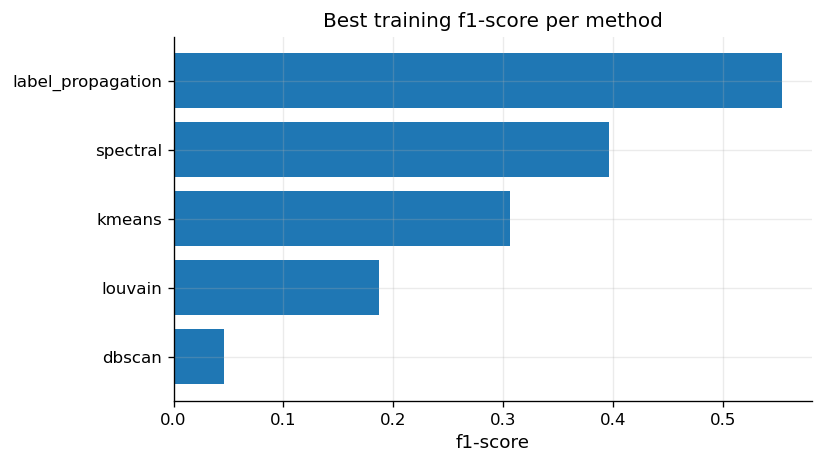

[WARN] No rows for method='dbscan' with param 'n_clusters'. Skipping plot.


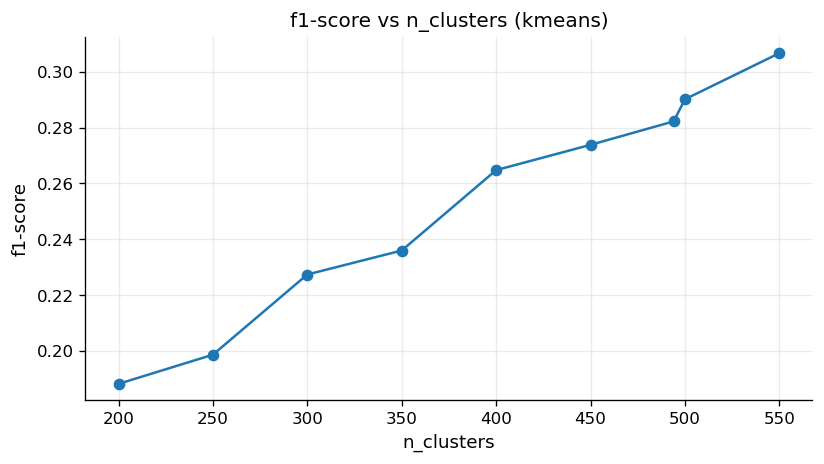

[WARN] No rows for method='label_propagation' with param 'n_clusters'. Skipping plot.


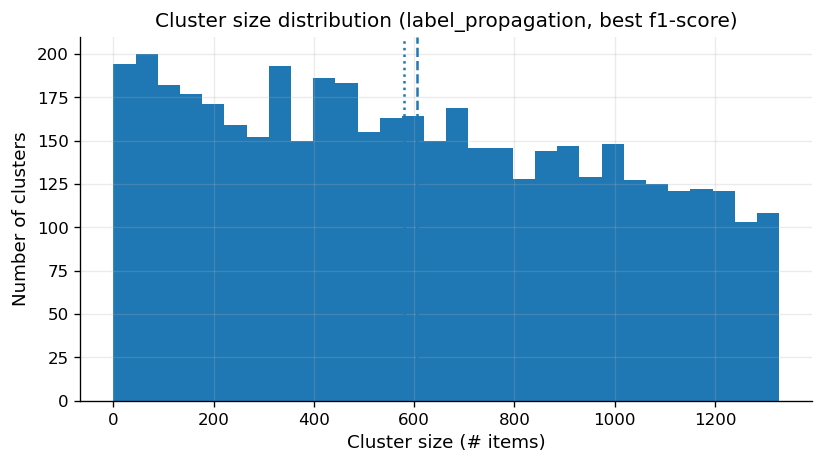

[WARN] test_df has no 'method' (and no merge keys). Returning train-only summary.


,method,train_f1_score,recall,accuracy,n_clusters,eps,min_samples,params
22,label_propagation,0.553748,0.582327,0.582327,NaN,NaN,NaN,{'seed': 2}
0,spectral,0.395891,0.434329,0.434329,550.0,NaN,NaN,{'n_clusters': 550}
11,kmeans,0.306647,0.352702,0.352702,550.0,NaN,NaN,{'n_clusters': 550}
9,louvain,0.187315,0.263191,0.263191,NaN,NaN,NaN,{}
10,dbscan,0.045628,0.115575,0.115575,NaN,0.9,2.0,"{'eps': 0.9, 'min_samples': 2}"


In [7]:
# --- Run for a single dataset ---
@dataclass(frozen=True)
class DatasetSpec:
    name: str
    training_csv: Path
    test_csv: Path


def run_dataset(spec: DatasetSpec, outdir: Path, metric: str = "f1_score") -> pd.DataFrame:
    _ensure_dir(outdir)

    train_df = load_training_stats(spec.training_csv)
    test_df = load_test_metrics(spec.test_csv)

    # Main results figures
    best_f1_per_method_barplot(train_df, outdir / f"{spec.name}_train_best_{metric}_per_method.png", metric=metric)

    # Optional hyperparameter sensitivity plots (edit methods/params to match your thesis)
    if "n_clusters" in train_df.columns:
        for m in sorted(train_df["method"].dropna().unique())[:3]:  # first 3 methods by name, adjust as needed
            f1_vs_param_lineplot(train_df, method=m, param_col="n_clusters",
                                 outpath=outdir / f"{spec.name}_{m}_f1_vs_n_clusters.png", metric=metric)

    # Cluster structure plot (best run overall)
    cluster_size_hist_best_run(train_df, outdir / f"{spec.name}_cluster_size_hist_best_run.png", metric=metric)

    summary = build_summary_table(train_df, test_df, metric=metric)
    summary.to_csv(outdir / f"{spec.name}_summary_table.csv", index=False)
    return summary


# Example (edit score/folders to match your project)
example_score = "321"
example = DatasetSpec(
    name=f"score_ge_1",
    training_csv=OUTPUT_DIR / example_score / "training_stats.csv",
    test_csv=OUTPUT_DIR / example_score / "test_metrics.csv",
)

single_outdir = FIGURES_DIR / "single_dataset" / example.name
print("Running:", example)
single_summary = run_dataset(example, single_outdir)
single_summary.head()

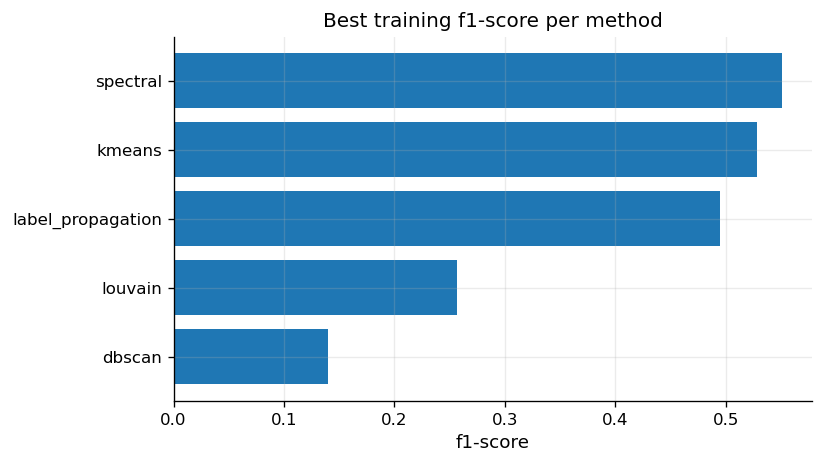

[WARN] No rows for method='dbscan' with param 'n_clusters'. Skipping plot.


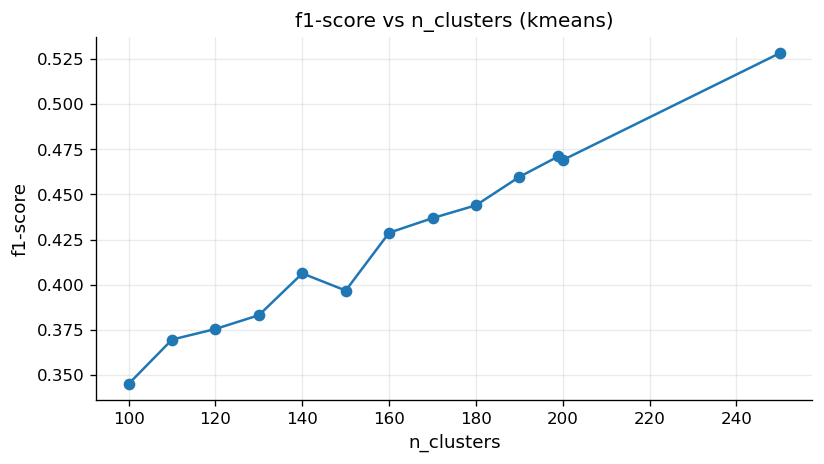

[WARN] No rows for method='label_propagation' with param 'n_clusters'. Skipping plot.


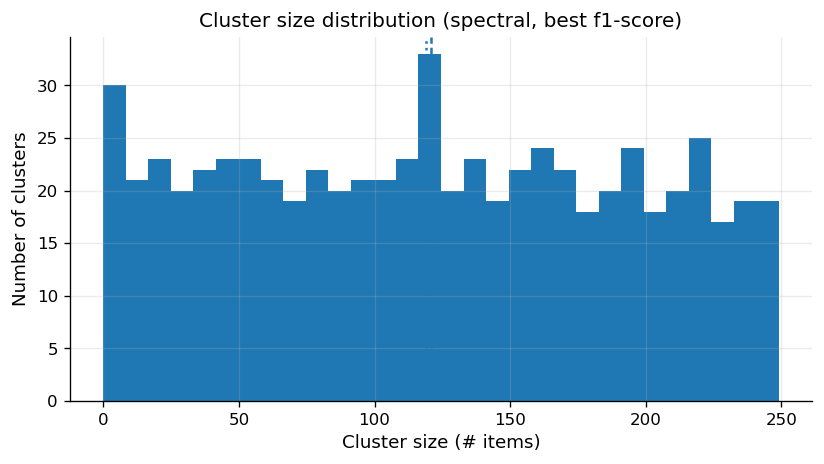

[WARN] test_df has no 'method' (and no merge keys). Returning train-only summary.


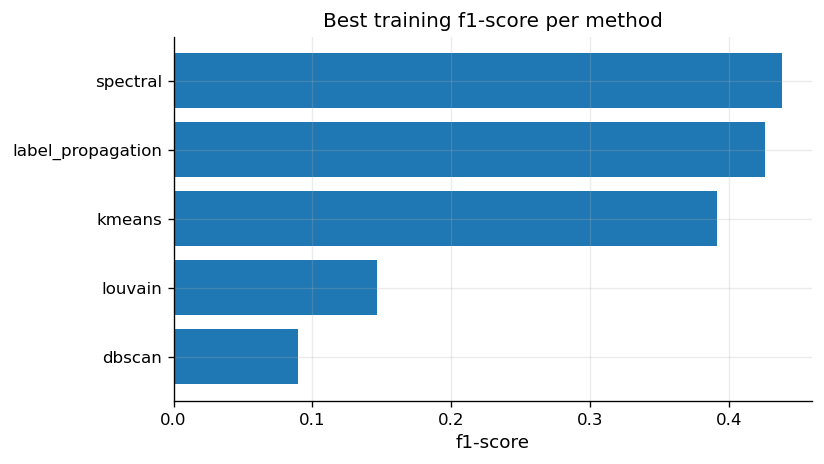

[WARN] No rows for method='dbscan' with param 'n_clusters'. Skipping plot.


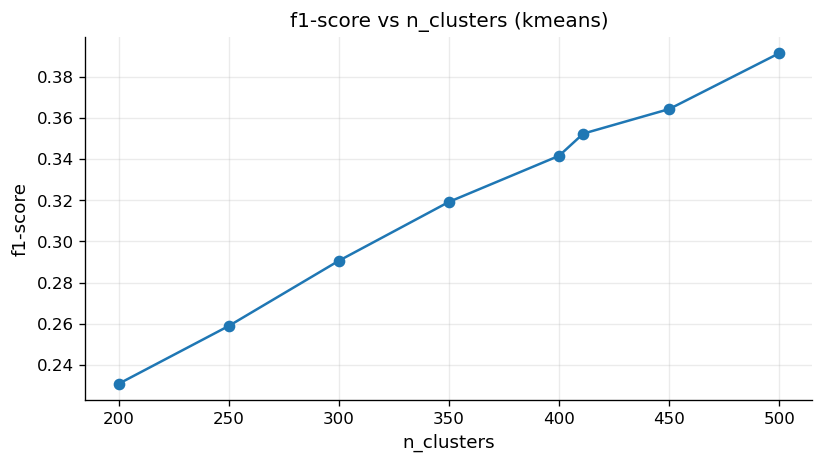

[WARN] No rows for method='label_propagation' with param 'n_clusters'. Skipping plot.


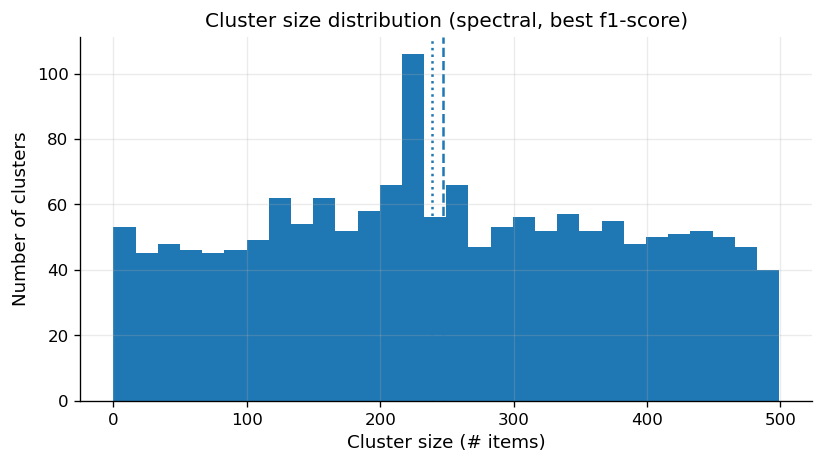

[WARN] test_df has no 'method' (and no merge keys). Returning train-only summary.


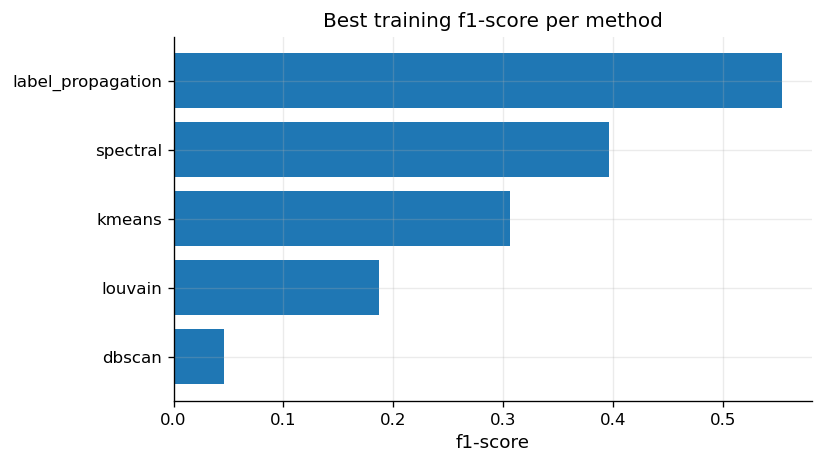

[WARN] No rows for method='dbscan' with param 'n_clusters'. Skipping plot.


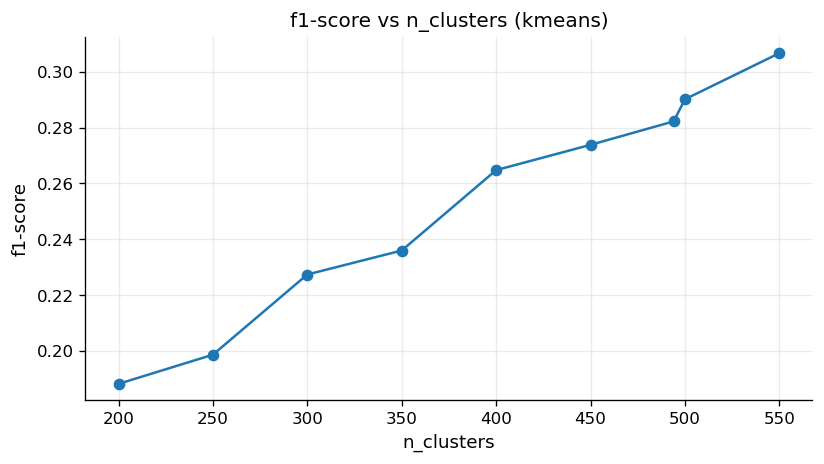

[WARN] No rows for method='label_propagation' with param 'n_clusters'. Skipping plot.


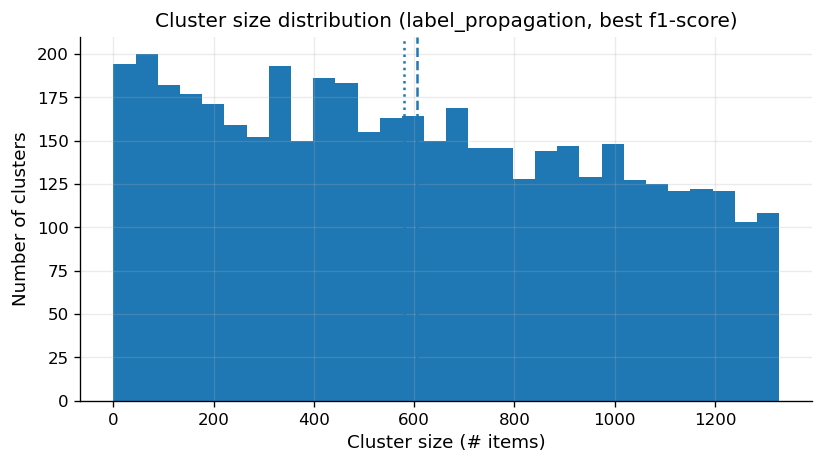

[WARN] test_df has no 'method' (and no merge keys). Returning train-only summary.
[WARN] score_eq_3: no test metric column among ['f1_score', 'test_f1_score', 'f1_score_test']. Skipping.
[WARN] score_ge_2: no test metric column among ['f1_score', 'test_f1_score', 'f1_score_test']. Skipping.
[WARN] score_ge_1: no test metric column among ['f1_score', 'test_f1_score', 'f1_score_test']. Skipping.


/tmp/ipykernel_2345891/2846866801.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


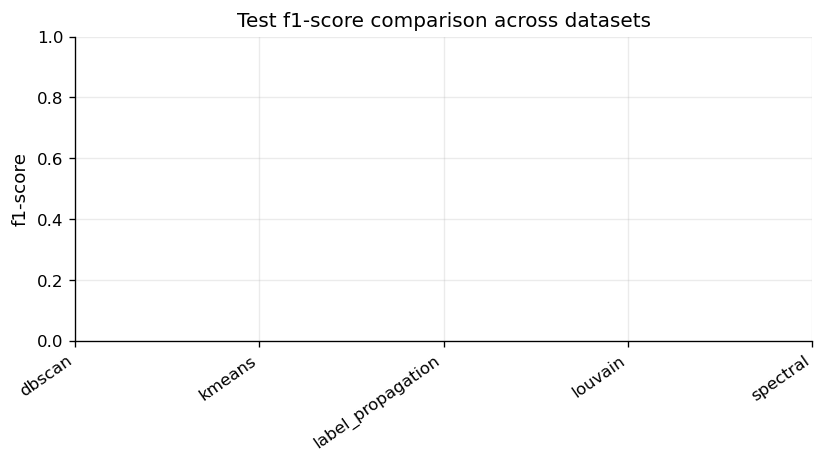

[WARN] score_eq_3: missing columns for gap plot. Skipping.
[WARN] score_ge_2: missing columns for gap plot. Skipping.
[WARN] score_ge_1: missing columns for gap plot. Skipping.


/tmp/ipykernel_2345891/2846866801.py:128: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


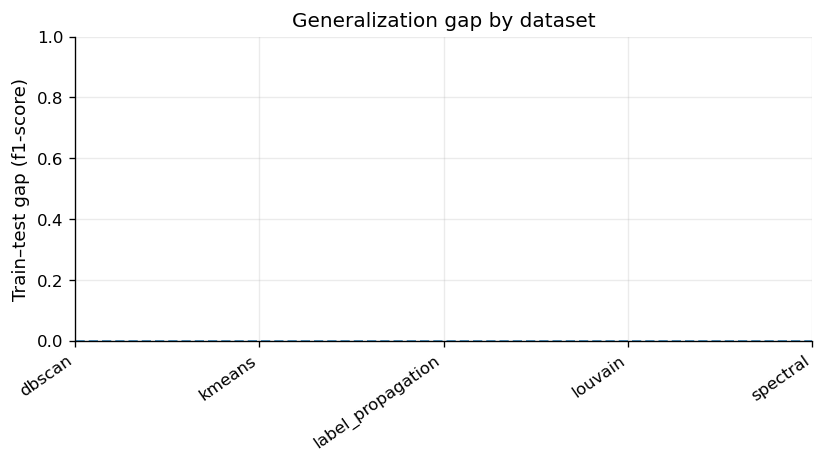

,dataset,method,train_f1_score,recall,accuracy,n_clusters,eps,min_samples,params
0,score_eq_3,spectral,0.550885,0.607945,0.607945,250.0,NaN,NaN,{'n_clusters': 250}
1,score_eq_3,kmeans,0.528188,0.582038,0.582038,250.0,NaN,NaN,{'n_clusters': 250}
2,score_eq_3,label_propagation,0.494750,0.555268,0.555268,NaN,NaN,NaN,{'seed': 0}
3,score_eq_3,louvain,0.256590,0.343696,0.343696,NaN,NaN,NaN,{}
4,score_eq_3,dbscan,0.139665,0.279793,0.279793,NaN,0.9,2.0,"{'eps': 0.9, 'min_samples': 2}"


In [8]:
# --- Run for multiple datasets (comparison) ---
dataset_map = {
    "score_eq_3": DatasetSpec(
        name="score_eq_3",
        training_csv=OUTPUT_DIR / "3" / "training_stats.csv",
        test_csv=OUTPUT_DIR / "3" / "test_metrics.csv",
    ),
    "score_ge_2": DatasetSpec(
        name="score_ge_2",
        training_csv=OUTPUT_DIR / "32" / "training_stats.csv",
        test_csv=OUTPUT_DIR / "32" / "test_metrics.csv",
    ),
    "score_ge_1": DatasetSpec(
        name="score_ge_1",
        training_csv=OUTPUT_DIR / "321" / "training_stats.csv",
        test_csv=OUTPUT_DIR / "321" / "test_metrics.csv",
    ),
}

all_summaries: Dict[str, pd.DataFrame] = {}
comparison_outdir = FIGURES_DIR / "all_datasets"
_ensure_dir(comparison_outdir)

for key, spec in dataset_map.items():
    outdir = comparison_outdir / spec.name
    if spec.training_csv.exists() and spec.test_csv.exists():
        all_summaries[spec.name] = run_dataset(spec, outdir)
    else:
        print(f"[SKIP] Missing CSVs for {spec.name}:")
        print("  ", spec.training_csv)
        print("  ", spec.test_csv)

# Comparison plots across datasets
if all_summaries:
    plot_dataset_comparison(all_summaries, comparison_outdir / "ALL_test_f1_comparison.png")
    plot_train_test_gap(all_summaries, comparison_outdir / "ALL_train_test_gap.png")

    # Combined table (long format)
    combined = []
    for ds_name, df in all_summaries.items():
        tmp = df.copy()
        tmp.insert(0, "dataset", ds_name)
        combined.append(tmp)
    combined_df = pd.concat(combined, ignore_index=True)
    combined_df.to_csv(comparison_outdir / "ALL_summary_table_long.csv", index=False)

combined_df.head() if all_summaries else None

In [11]:
combined_df

,dataset,method,train_f1_score,recall,accuracy,n_clusters,eps,min_samples,params
0,score_eq_3,spectral,0.550885,0.607945,0.607945,250.0,NaN,NaN,{'n_clusters': 250}
1,score_eq_3,kmeans,0.528188,0.582038,0.582038,250.0,NaN,NaN,{'n_clusters': 250}
2,score_eq_3,label_propagation,0.494750,0.555268,0.555268,NaN,NaN,NaN,{'seed': 0}
3,score_eq_3,louvain,0.256590,0.343696,0.343696,NaN,NaN,NaN,{}
4,score_eq_3,dbscan,0.139665,0.279793,0.279793,NaN,0.9,2.0,"{'eps': 0.9, 'min_samples': 2}"
5,score_ge_2,spectral,0.437871,0.496142,0.496142,500.0,NaN,NaN,{'n_clusters': 500}
6,score_ge_2,label_propagation,0.425410,0.482253,0.482253,NaN,NaN,NaN,{'seed': 1}
7,score_ge_2,kmeans,0.391439,0.448302,0.448302,500.0,NaN,NaN,{'n_clusters': 500}
8,score_ge_2,louvain,0.146501,0.235340,0.235340,NaN,NaN,NaN,{}
9,score_ge_2,dbscan,0.089572,0.182485,0.182485,NaN,0.9,2.0,"{'eps': 0.9, 'min_samples': 2}"


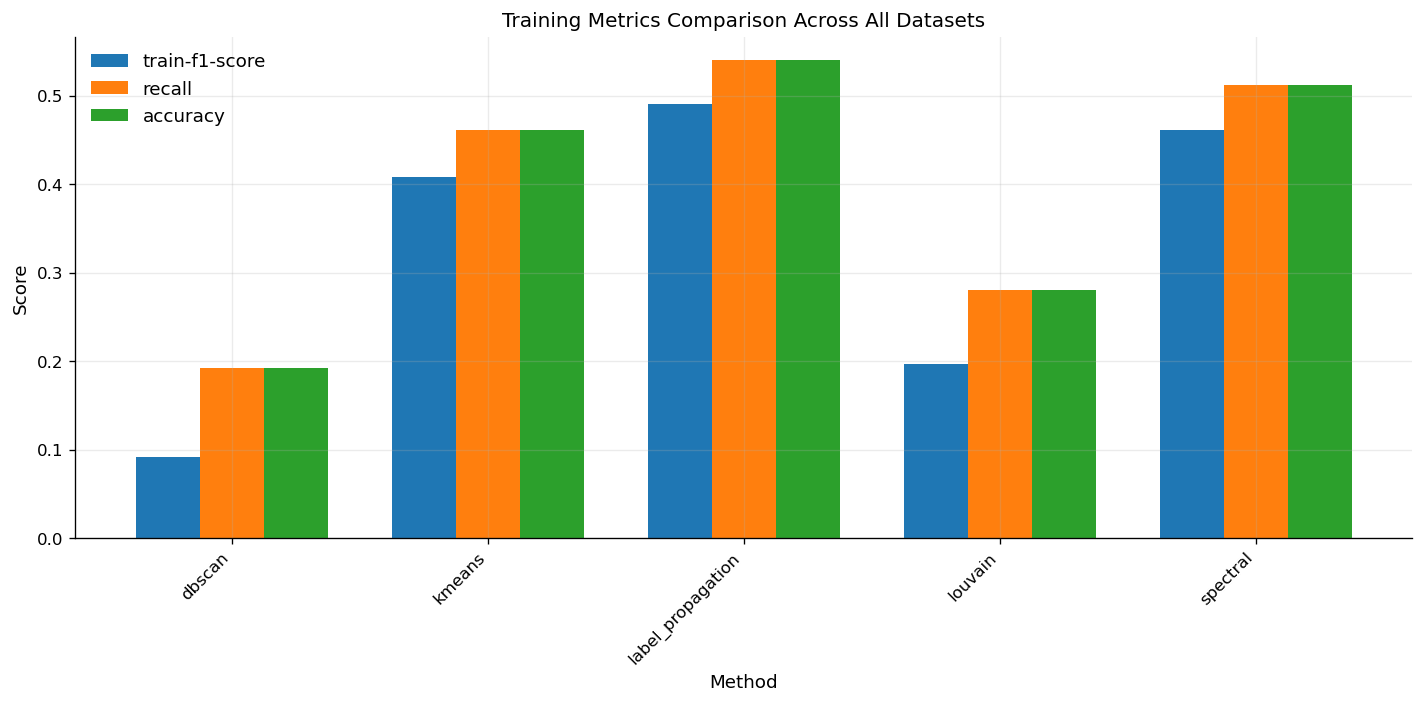

In [ ]:
# Create a grouped barplot for f1_score, recall, and accuracy across all datasets
plt.figure(figsize=(12, 6))

methods = sorted(combined_df["method"].unique())
datasets = sorted(combined_df["dataset"].unique())
x = np.arange(len(methods))
width = 0.25

for i, metric in enumerate(["train_f1_score", "recall", "accuracy"]):
    values = []
    for m in methods:
        # Average across datasets for each method
        val = combined_df[combined_df["method"] == m][metric].mean()
        values.append(val)
    
    plt.bar(x + i*width, values, width, label=metric.replace("_", "-"))

plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Training Metrics Comparison Across All Datasets")
plt.xticks(x + width, methods, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy
sns.barplot(x='Model', y='accuracy', data=df.groupby('Model')['accuracy'].mean().reset_index(), palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Average Accuracy for Each Model')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Average Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Precision
sns.barplot(x='Model', y='precision', data=df.groupby('Model')['precision'].mean().reset_index(), palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Average Precision for Each Model')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Average Precision')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Recall
sns.barplot(x='Model', y='recall', data=df.groupby('Model')['recall'].mean().reset_index(), palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Average Recall for Each Model')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Average Recall')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: F1 Score
sns.barplot(x='Model', y='f1-score', data=df.groupby('Model')['f1-score'].mean().reset_index(), palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Average F1 Score for Each Model')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Average F1 Score')
axes[1, 1].tick_params(axis='x', rotation=45)

panel_labels = ['A', 'B', 'C', 'D']

for ax, label in zip(axes.flat, panel_labels):
    ax.text(
        -0.1, 1.1, label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
plt.show()